<a href="https://colab.research.google.com/github/Juanca25-10/Laboratorios_Collab_Repo/blob/main/Laboratorio_16_Juan_Camilo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

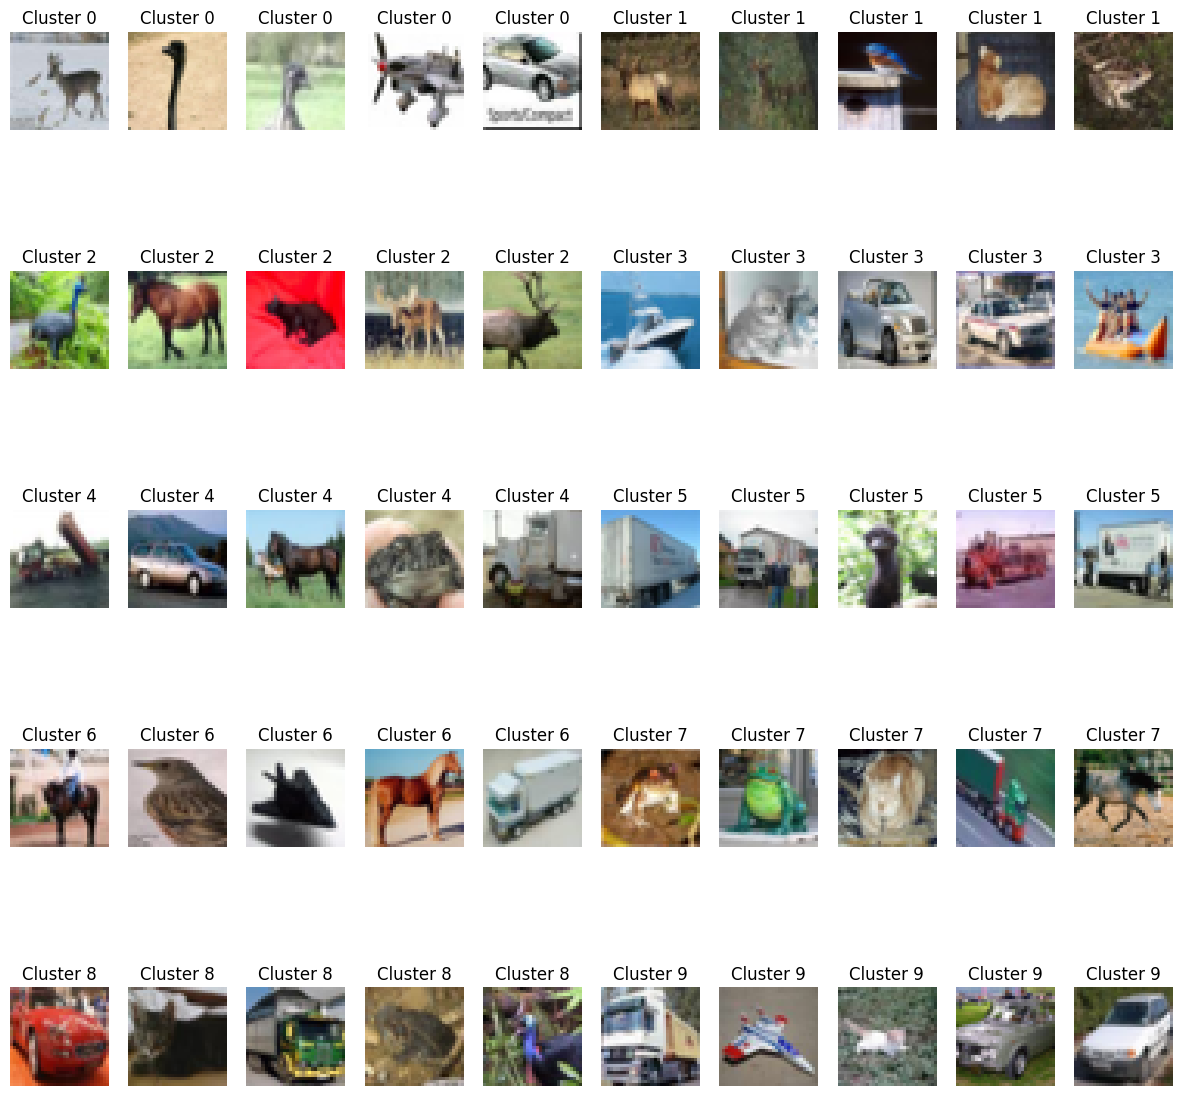

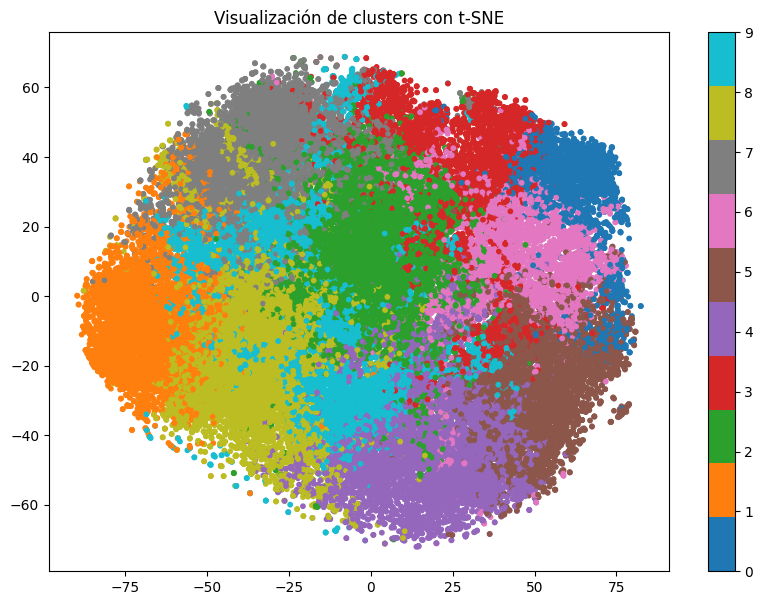

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from tensorflow.keras.datasets import cifar10

# Cargar el dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Reorganizar los datos
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Aplicar K-Means
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X_train_flat)
clusters = kmeans.labels_

# Visualizar los clusters
def plot_images(images, titles, rows, cols):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis('off')
    plt.show()

sample_images = []
sample_titles = []
for i in range(10):
    idx = np.where(clusters == i)[0][:5]
    sample_images.extend(X_train[idx])
    sample_titles.extend([f"Cluster {i}"] * 5)

plot_images(sample_images, sample_titles, rows=5, cols=10)

# Reducir dimensionalidad con PCA
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_train_flat)

# Visualización con t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='tab10', s=10)
plt.title('Visualización de clusters con t-SNE')
plt.colorbar()
plt.show()